In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AffinityPropagation

In [2]:
df = pd.read_csv('Mall_Customers.csv')

In [3]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values
X

array([[ 19,  15,  39],
       [ 21,  15,  81],
       [ 20,  16,   6],
       [ 23,  16,  77],
       [ 31,  17,  40],
       [ 22,  17,  76],
       [ 35,  18,   6],
       [ 23,  18,  94],
       [ 64,  19,   3],
       [ 30,  19,  72],
       [ 67,  19,  14],
       [ 35,  19,  99],
       [ 58,  20,  15],
       [ 24,  20,  77],
       [ 37,  20,  13],
       [ 22,  20,  79],
       [ 35,  21,  35],
       [ 20,  21,  66],
       [ 52,  23,  29],
       [ 35,  23,  98],
       [ 35,  24,  35],
       [ 25,  24,  73],
       [ 46,  25,   5],
       [ 31,  25,  73],
       [ 54,  28,  14],
       [ 29,  28,  82],
       [ 45,  28,  32],
       [ 35,  28,  61],
       [ 40,  29,  31],
       [ 23,  29,  87],
       [ 60,  30,   4],
       [ 21,  30,  73],
       [ 53,  33,   4],
       [ 18,  33,  92],
       [ 49,  33,  14],
       [ 21,  33,  81],
       [ 42,  34,  17],
       [ 30,  34,  73],
       [ 36,  37,  26],
       [ 20,  37,  75],
       [ 65,  38,  35],
       [ 24,  38

In [4]:



af = AffinityPropagation(damping=0.9, preference=-50)
labels = af.fit_predict(X)



n_clusters = len(af.cluster_centers_indices_)


print(f"Clusters found: {n_clusters}")
print(f"\nCluster Centers:\n{pd.DataFrame(af.cluster_centers_, columns=['Age', 'Income', 'Spending Score']).round(1)}")



Clusters found: 123

Cluster Centers:
     Age  Income  Spending Score
0     19      15              39
1     20      16               6
2     23      16              77
3     31      17              40
4     35      18               6
..   ...     ...             ...
118   35     120              79
119   45     126              28
120   32     126              74
121   32     137              18
122   30     137              83

[123 rows x 3 columns]


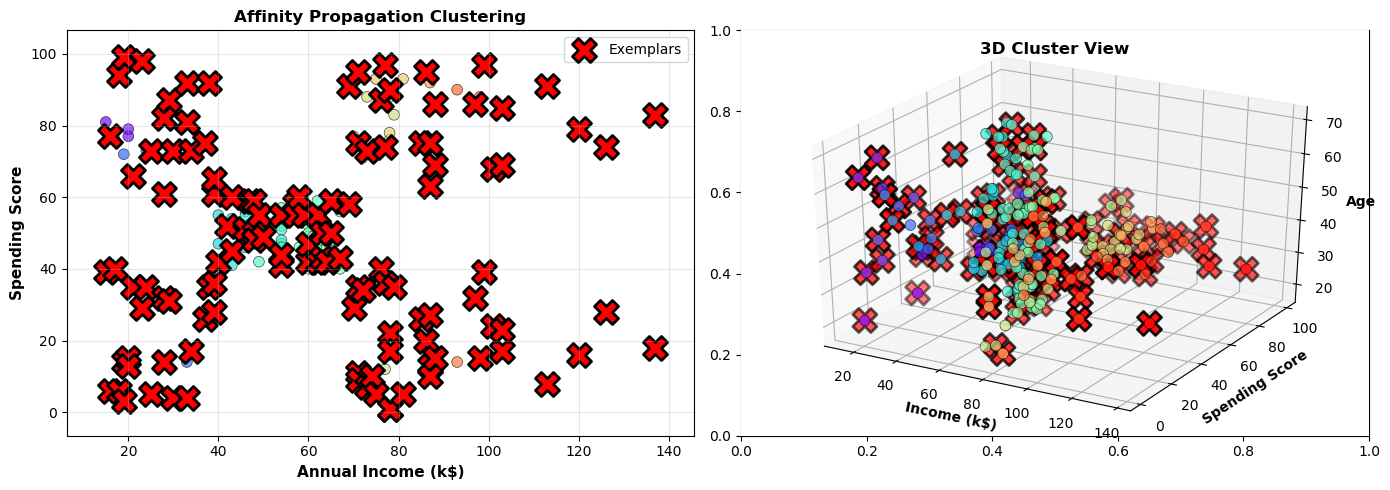

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


scatter = axes[0].scatter(X[:, 1], X[:, 2], c=labels, cmap='rainbow', s=60, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[0].scatter(af.cluster_centers_[:, 1], af.cluster_centers_[:, 2], c='red', marker='X',
                s=300, edgecolors='black', linewidth=2, label='Exemplars')
axes[0].set_xlabel('Annual Income (k$)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Spending Score', fontsize=11, fontweight='bold')
axes[0].set_title('Affinity Propagation Clustering', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

from mpl_toolkits.mplot3d import Axes3D
ax = fig.add_subplot(1, 2, 2, projection='3d')
scatter = ax.scatter(X[:, 1], X[:, 2], X[:, 0], c=labels, cmap='rainbow', s=60, alpha=0.7, edgecolors='black', linewidth=0.5)
ax.scatter(af.cluster_centers_[:, 1], af.cluster_centers_[:, 2], af.cluster_centers_[:, 0], c='red', marker='X',
s=300, edgecolors='black', linewidth=2)
ax.set_xlabel('Income (k$)', fontweight='bold')
ax.set_ylabel('Spending Score', fontweight='bold')
ax.set_zlabel('Age', fontweight='bold')
ax.set_title('3D Cluster View', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()